# Barista Results Analysis
Analysis of AI agent performance across 35 Java classes × 5 runs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COMPLEXITY_ORDER = ['simple', 'moderate', 'complex']
COMPLEXITY_COLORS = {'simple': '#4ade80', 'moderate': '#fb923c', 'complex': '#f87171'}

## 1. Data Loading & Preparation

Join workflow metrics with complexity ratings. Exclude:\n- **\"none\" complexity** classes (no typestate protocol — not meaningful for analysis)\n- **Zero-cost runs** (7 runs with $0 cost, likely timeouts/failures — flagged separately)

In [2]:
# Load workflow metrics
df = pd.read_csv('workflow_metrics.csv')
print(f"Loaded {len(df)} runs across {df['class_name'].nunique()} classes")

# Load complexity ratings
comp_df = pd.read_csv('manual/complexity/complexity_review_final.csv', skiprows=4)
comp_df = comp_df[['Class', 'Reviewer1_Complexity', 'Reviewer2_Complexity', 'Final_Complexity', 'Final_Factors']]
comp_df.columns = ['full_class_name', 'reviewer1', 'reviewer2', 'complexity', 'factors']

# Map full class names to folder names (last segment, lowercased)
comp_df['class_name'] = comp_df['full_class_name'].str.rsplit('.', n=1).str[-1].str.lower()
# Fix known typo
comp_df.loc[comp_df['class_name'] == 'dragsourcecontext', 'class_name'] = 'dragsoucecontext'

# Join
df = df.merge(comp_df[['class_name', 'full_class_name', 'complexity', 'factors', 'reviewer1', 'reviewer2']], on='class_name', how='left')
print(f"Complexity join: {df['complexity'].notna().sum()}/{len(df)} matched")

# Flag and exclude zero-cost runs
zero_cost = df[df['total_cost_usd'] == 0].copy()
print(f"\nExcluded {len(zero_cost)} zero-cost runs (likely timeouts):")
print(zero_cost[['class_name', 'run', 'wall_clock_secs', 'total_turns']].to_string(index=False))

# Exclude "none" complexity and zero-cost runs
df_all = df.copy()  # keep full dataset for reference
df = df[(df['complexity'] != 'none') & (df['total_cost_usd'] > 0)].copy()
df['complexity'] = pd.Categorical(df['complexity'], categories=COMPLEXITY_ORDER, ordered=True)
print(f"\nAnalysis dataset: {len(df)} runs across {df['class_name'].nunique()} classes")
print(df['complexity'].value_counts().sort_index())

Loaded 175 runs across 35 classes
Complexity join: 175/175 matched

Excluded 7 zero-cost runs (likely timeouts):
       class_name  run  wall_clock_secs  total_turns
   choicecallback    1          1080.68          219
   choicecallback    4          1082.18          143
  imagewriteparam    4          1174.23           66
pipedoutputstream    1             0.00           13
      pipedwriter    4          1084.68           73
  zipoutputstream    2          1235.55          101
  zipoutputstream    4          1082.40          105

Analysis dataset: 138 runs across 29 classes
complexity
simple      45
moderate    29
complex     64
Name: count, dtype: int64


## 2. Overview — Cost & Duration Distributions

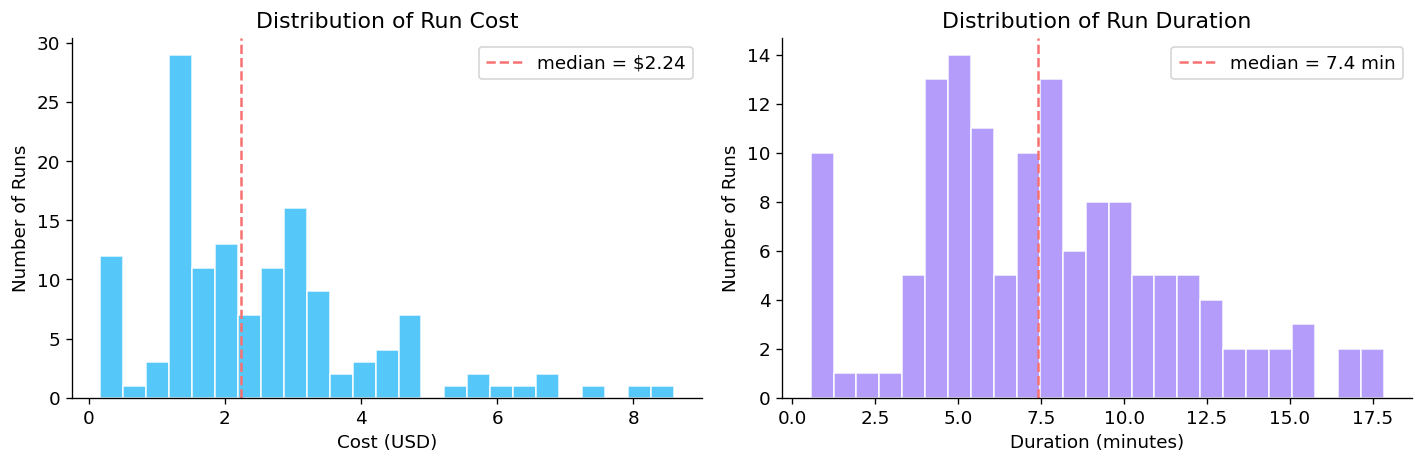

            n_runs  n_classes  cost_mean  cost_median  cost_std  \
complexity                                                        
simple          45          9       2.05         1.48      1.21   
moderate        29          7       2.56         2.19      1.70   
complex         64         13       2.93         2.90      1.85   

            duration_mean  duration_median  turns_mean  tool_calls_mean  
complexity                                                               
simple             371.48           313.33       74.78            67.51  
moderate           466.37           436.53       69.41            61.31  
complex            515.15           512.21       98.48            91.45  


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['total_cost_usd'], bins=25, color='#38bdf8', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Cost (USD)')
axes[0].set_ylabel('Number of Runs')
axes[0].set_title('Distribution of Run Cost')
axes[0].axvline(df['total_cost_usd'].median(), color='#f87171', ls='--', label=f"median = ${df['total_cost_usd'].median():.2f}")
axes[0].legend()

axes[1].hist(df['wall_clock_secs'] / 60, bins=25, color='#a78bfa', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Number of Runs')
axes[1].set_title('Distribution of Run Duration')
axes[1].axvline(df['wall_clock_secs'].median() / 60, color='#f87171', ls='--', label=f"median = {df['wall_clock_secs'].median()/60:.1f} min")
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight')
plt.show()

# Summary table
summary = df.groupby('complexity').agg(
    n_runs=('total_cost_usd', 'count'),
    n_classes=('class_name', 'nunique'),
    cost_mean=('total_cost_usd', 'mean'),
    cost_median=('total_cost_usd', 'median'),
    cost_std=('total_cost_usd', 'std'),
    duration_mean=('wall_clock_secs', 'mean'),
    duration_median=('wall_clock_secs', 'median'),
    turns_mean=('total_turns', 'mean'),
    tool_calls_mean=('total_tool_calls', 'mean'),
).round(2)
print(summary)

## 3. Complexity vs. Effort\n\n**Hypothesis:** Complex classes should take longer (and cost more) than simple ones.

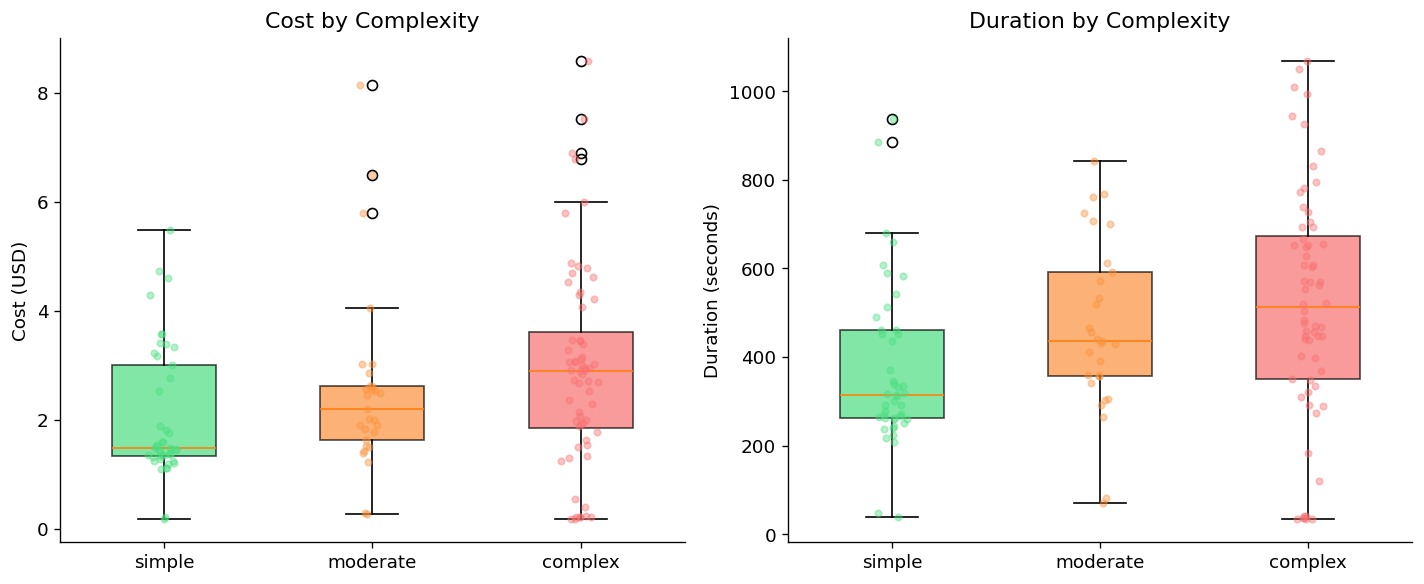

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, ylabel, title in [
    (axes[0], 'total_cost_usd', 'Cost (USD)', 'Cost by Complexity'),
    (axes[1], 'wall_clock_secs', 'Duration (seconds)', 'Duration by Complexity'),
]:
    data = [df[df['complexity'] == c][col].values for c in COMPLEXITY_ORDER]
    bp = ax.boxplot(data, tick_labels=COMPLEXITY_ORDER, patch_artist=True, widths=0.5)
    for patch, c in zip(bp['boxes'], COMPLEXITY_ORDER):
        patch.set_facecolor(COMPLEXITY_COLORS[c])
        patch.set_alpha(0.7)
    # Overlay individual points
    for i, c in enumerate(COMPLEXITY_ORDER):
        vals = df[df['complexity'] == c][col]
        ax.scatter(np.random.normal(i + 1, 0.04, size=len(vals)), vals,
                   alpha=0.4, s=15, color=COMPLEXITY_COLORS[c], zorder=3)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('fig_complexity_boxplots.png', bbox_inches='tight')
plt.show()

In [5]:
# Kruskal-Wallis test: does complexity level predict cost / duration?
for col, label in [('total_cost_usd', 'Cost'), ('wall_clock_secs', 'Duration')]:
    groups = [df[df['complexity'] == c][col].values for c in COMPLEXITY_ORDER]
    stat, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis ({label}): H={stat:.3f}, p={p:.4f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'}")

    # Pairwise Mann-Whitney U with Bonferroni correction if significant
    if p < 0.05:
        pairs = [('simple', 'moderate'), ('simple', 'complex'), ('moderate', 'complex')]
        n_comparisons = len(pairs)
        for c1, c2 in pairs:
            g1 = df[df['complexity'] == c1][col].values
            g2 = df[df['complexity'] == c2][col].values
            u_stat, u_p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            adjusted_p = min(u_p * n_comparisons, 1.0)  # Bonferroni
            sig = '***' if adjusted_p < 0.001 else '**' if adjusted_p < 0.01 else '*' if adjusted_p < 0.05 else 'ns'
            print(f"  {c1} vs {c2}: U={u_stat:.1f}, p={adjusted_p:.4f} {sig}")
    print()

Kruskal-Wallis (Cost): H=10.290, p=0.0058 **
  simple vs moderate: U=471.0, p=0.1352 ns
  simple vs complex: U=968.0, p=0.0111 *
  moderate vs complex: U=733.0, p=0.3202 ns

Kruskal-Wallis (Duration): H=14.086, p=0.0009 ***
  simple vs moderate: U=411.0, p=0.0229 *
  simple vs complex: U=874.0, p=0.0015 **
  moderate vs complex: U=796.0, p=0.8264 ns



## 4. Variance / Reproducibility\n\nHow stable are repeated runs of the same class? Coefficient of variation (CV = std/mean) per class.

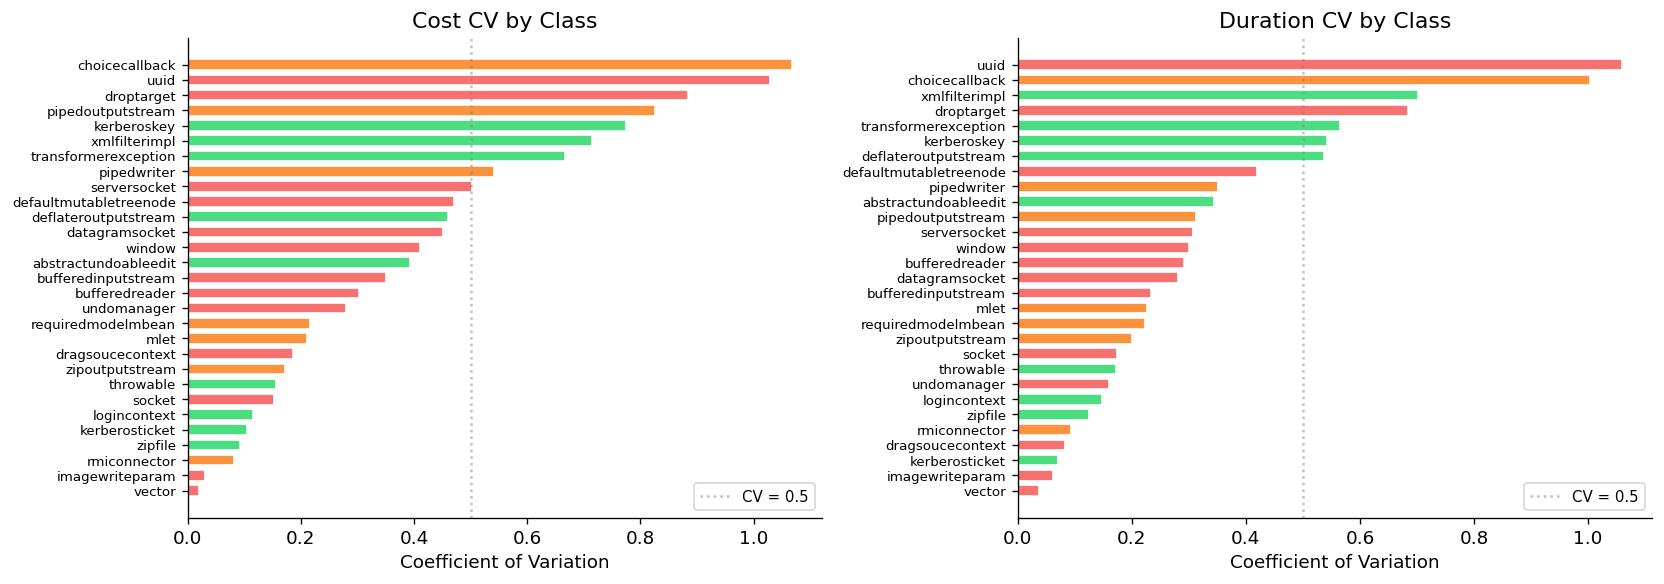

Median CV by complexity:
            cost_cv  dur_cv
complexity                 
simple        0.393   0.345
moderate      0.216   0.226
complex       0.350   0.281


In [6]:
# Per-class CV for cost
class_stats = df.groupby(['class_name', 'complexity']).agg(
    cost_mean=('total_cost_usd', 'mean'),
    cost_std=('total_cost_usd', 'std'),
    dur_mean=('wall_clock_secs', 'mean'),
    dur_std=('wall_clock_secs', 'std'),
    n=('total_cost_usd', 'count'),
).reset_index()
class_stats['cost_cv'] = class_stats['cost_std'] / class_stats['cost_mean']
class_stats['dur_cv'] = class_stats['dur_std'] / class_stats['dur_mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cv_col, title in [
    (axes[0], 'cost_cv', 'Cost CV by Class'),
    (axes[1], 'dur_cv', 'Duration CV by Class'),
]:
    sorted_df = class_stats.sort_values(cv_col, ascending=True)
    colors = [COMPLEXITY_COLORS[c] for c in sorted_df['complexity']]
    ax.barh(range(len(sorted_df)), sorted_df[cv_col], color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(sorted_df)))
    ax.set_yticklabels(sorted_df['class_name'], fontsize=8)
    ax.set_xlabel('Coefficient of Variation')
    ax.set_title(title)
    ax.axvline(0.5, color='gray', ls=':', alpha=0.5, label='CV = 0.5')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_variance.png', bbox_inches='tight')
plt.show()

# Is variance correlated with complexity?
print("Median CV by complexity:")
print(class_stats.groupby('complexity')[['cost_cv', 'dur_cv']].median().round(3))

## 5. Agent Behavior\n\nWhich sub-agents consume the most turns? How does agent workload vary by complexity?

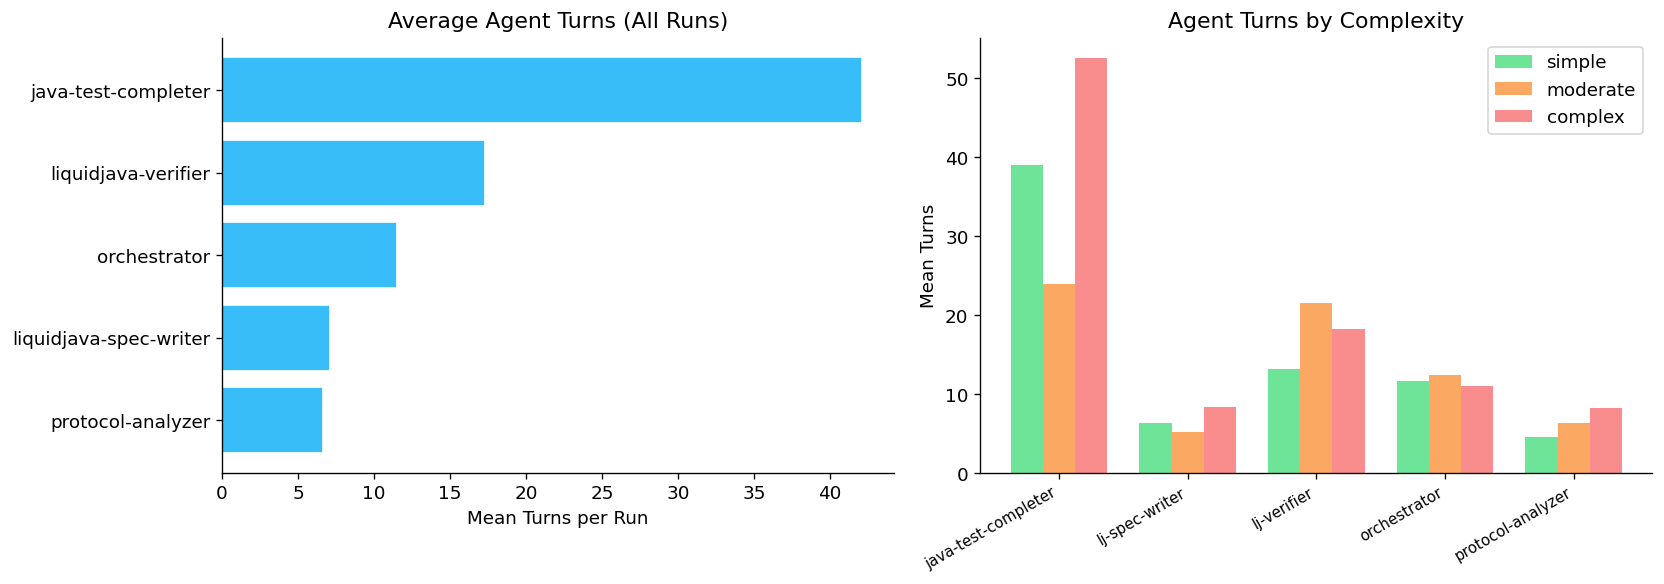

In [7]:
agent_cols = [c for c in df.columns if c.startswith('agent_turns_')]
agent_names = [c.replace('agent_turns_', '') for c in agent_cols]

# Overall mean turns by agent
agent_means = df[agent_cols].mean().sort_values(ascending=True)
agent_means.index = [c.replace('agent_turns_', '') for c in agent_means.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: overall agent turns
axes[0].barh(agent_means.index, agent_means.values, color='#38bdf8', edgecolor='white')
axes[0].set_xlabel('Mean Turns per Run')
axes[0].set_title('Average Agent Turns (All Runs)')

# Grouped bar: agent turns by complexity
x = np.arange(len(agent_names))
width = 0.25
for i, c in enumerate(COMPLEXITY_ORDER):
    means = df[df['complexity'] == c][agent_cols].mean().values
    axes[1].bar(x + i * width, means, width, label=c, color=COMPLEXITY_COLORS[c], alpha=0.8)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([n.replace('liquidjava-', 'lj-') for n in agent_names], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Mean Turns')
axes[1].set_title('Agent Turns by Complexity')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_agent_turns.png', bbox_inches='tight')
plt.show()

## 6. Tool Usage Patterns

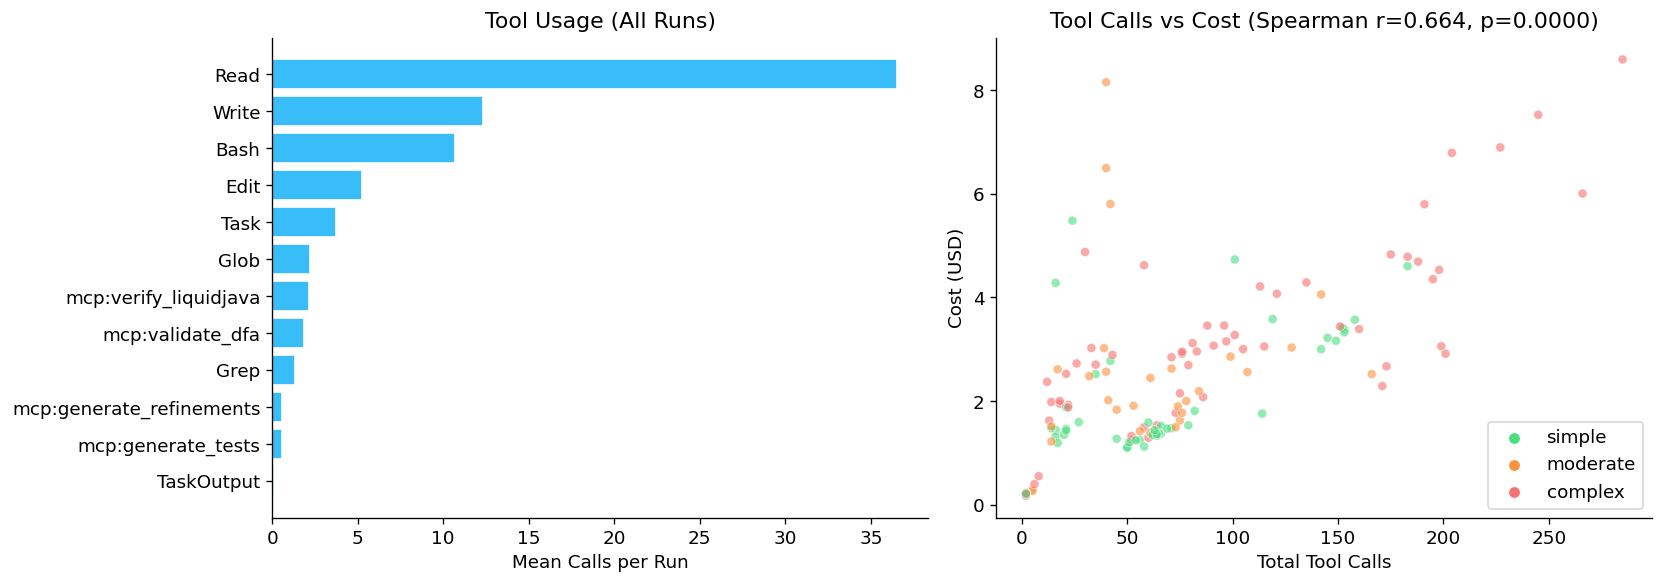

In [8]:
tool_cols = [c for c in df.columns if c.startswith('tool_')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall tool usage
tool_means = df[tool_cols].mean().sort_values(ascending=True)
tool_means.index = [c.replace('tool_', '').replace('mcp__barista_tools__', 'mcp:') for c in tool_means.index]
axes[0].barh(tool_means.index, tool_means.values, color='#38bdf8', edgecolor='white')
axes[0].set_xlabel('Mean Calls per Run')
axes[0].set_title('Tool Usage (All Runs)')

# Scatter: tool calls vs cost
axes[1].scatter(df['total_tool_calls'], df['total_cost_usd'],
                c=[COMPLEXITY_COLORS[c] for c in df['complexity']], alpha=0.6, s=30, edgecolors='white', linewidth=0.5)
r, p = stats.spearmanr(df['total_tool_calls'], df['total_cost_usd'])
axes[1].set_xlabel('Total Tool Calls')
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Tool Calls vs Cost (Spearman r={r:.3f}, p={p:.4f})')
# Legend
for c in COMPLEXITY_ORDER:
    axes[1].scatter([], [], color=COMPLEXITY_COLORS[c], label=c, s=30)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_tool_usage.png', bbox_inches='tight')
plt.show()

## 7. Tool Usage Heatmap by Complexity

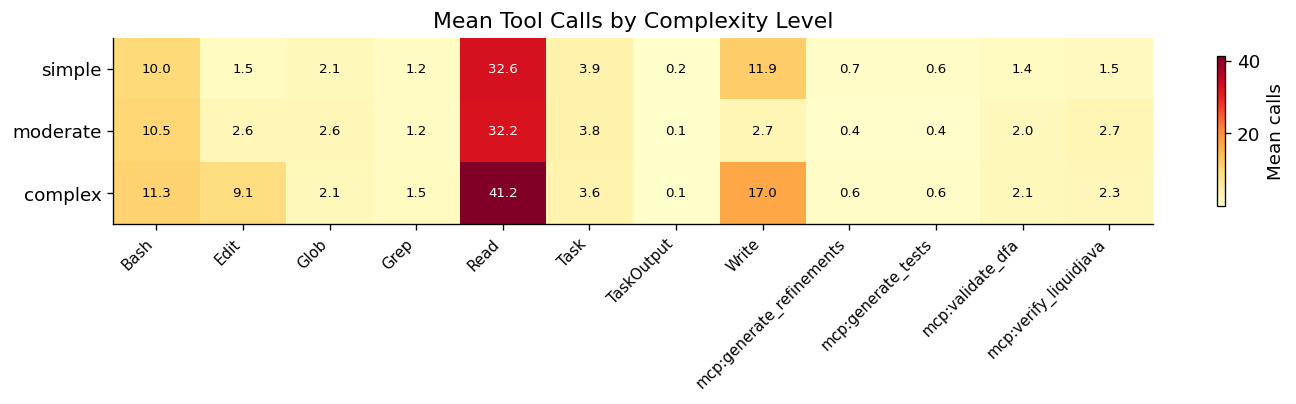

In [9]:
heatmap_data = df.groupby('complexity')[tool_cols].mean()
heatmap_data.columns = [c.replace('tool_', '').replace('mcp__barista_tools__', 'mcp:') for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(COMPLEXITY_ORDER)))
ax.set_yticklabels(COMPLEXITY_ORDER)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right', fontsize=9)
ax.set_title('Mean Tool Calls by Complexity Level')

# Annotate cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        color = 'white' if val > heatmap_data.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Mean calls')
plt.tight_layout()
plt.savefig('fig_tool_heatmap.png', bbox_inches='tight')
plt.show()

## 8. Outlier Analysis\n\nInvestigate the 7 zero-cost (likely failed/timed-out) runs and the most expensive runs.

=== Zero-cost runs (excluded from analysis) ===
       class_name  run  wall_clock_secs  total_turns  total_tool_calls  total_agent_spawns
   choicecallback    1          1080.68          219               214                   4
   choicecallback    4          1082.18          143               138                   4
  imagewriteparam    4          1174.23           66                56                   4
pipedoutputstream    1             0.00           13                 9                   3
      pipedwriter    4          1084.68           73                64                   4
  zipoutputstream    2          1235.55          101                95                   4
  zipoutputstream    4          1082.40          105                91                   5

Classes affected: ['choicecallback', 'imagewriteparam', 'pipedoutputstream', 'pipedwriter', 'zipoutputstream']
Mean wall clock of zero-cost runs: 963s

=== Top 10 most expensive runs ===
       class_name  run complexity  t

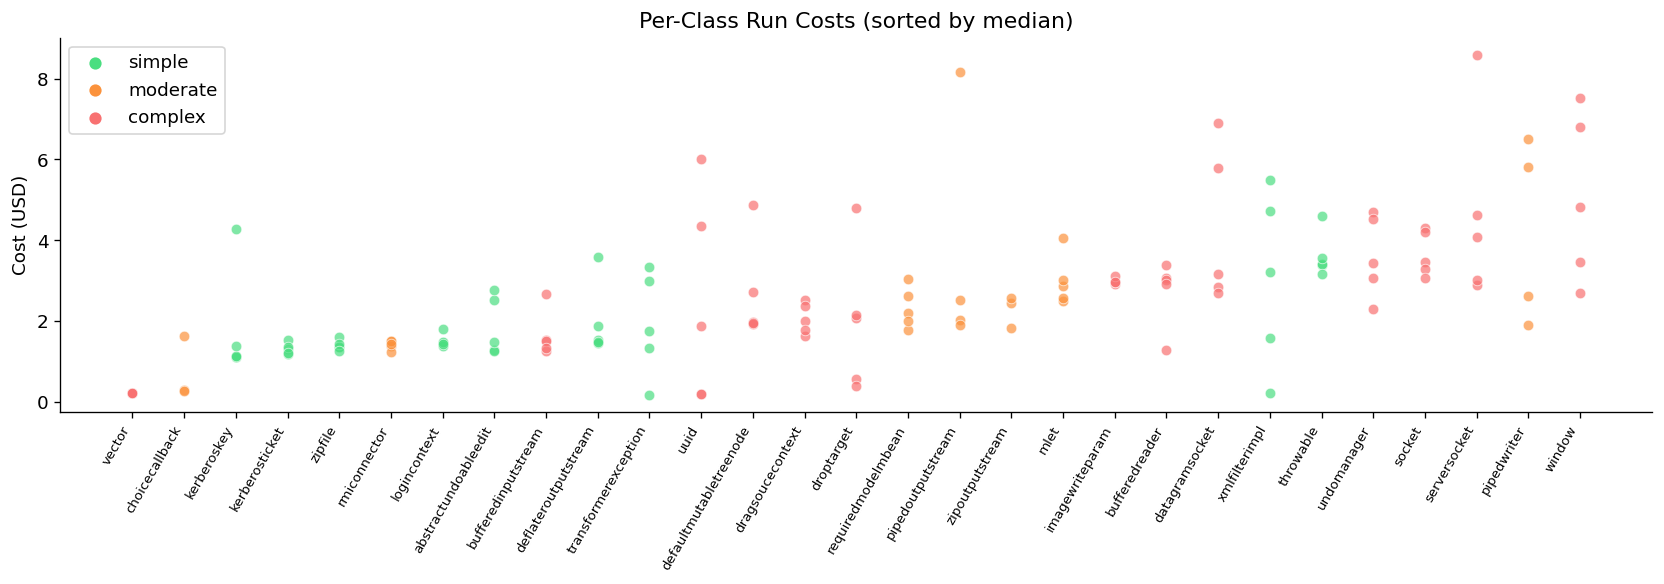

In [10]:
# Zero-cost runs
print("=== Zero-cost runs (excluded from analysis) ===")
print(zero_cost[['class_name', 'run', 'wall_clock_secs', 'total_turns', 'total_tool_calls', 'total_agent_spawns']].to_string(index=False))
print(f"\nClasses affected: {zero_cost['class_name'].unique().tolist()}")
print(f"Mean wall clock of zero-cost runs: {zero_cost['wall_clock_secs'].mean():.0f}s")

# Most expensive runs (top 10)
print("\n=== Top 10 most expensive runs ===")
top = df.nlargest(10, 'total_cost_usd')[['class_name', 'run', 'complexity', 'total_cost_usd', 'wall_clock_secs', 'total_turns']]
print(top.to_string(index=False))

# Strip plot: per-class cost with outliers visible
fig, ax = plt.subplots(figsize=(14, 5))
classes_sorted = df.groupby('class_name')['total_cost_usd'].median().sort_values().index
for i, cls in enumerate(classes_sorted):
    subset = df[df['class_name'] == cls]
    c = COMPLEXITY_COLORS[subset['complexity'].iloc[0]]
    ax.scatter([i] * len(subset), subset['total_cost_usd'], color=c, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xticks(range(len(classes_sorted)))
ax.set_xticklabels(classes_sorted, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Cost (USD)')
ax.set_title('Per-Class Run Costs (sorted by median)')
for c in COMPLEXITY_ORDER:
    ax.scatter([], [], color=COMPLEXITY_COLORS[c], label=c, s=40)
ax.legend()
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()

## 9. Inter-Reviewer Agreement\n\nCohen's kappa for the two complexity reviewers.

In [11]:
# Inter-reviewer agreement
review_df = comp_df[['full_class_name', 'reviewer1', 'reviewer2']].copy()
review_df['reviewer1'] = review_df['reviewer1'].fillna('').str.strip()
review_df['reviewer2'] = review_df['reviewer2'].fillna('').str.strip()
review_df = review_df[(review_df['reviewer1'] != '') & (review_df['reviewer2'] != '')]

labels = ['none', 'simple', 'moderate', 'complex']

# Cohen's kappa (manual — no sklearn dependency)
def cohens_kappa_weighted(r1, r2, labels, weights='linear'):
    """Compute weighted Cohen's kappa."""
    n = len(labels)
    label_idx = {l: i for i, l in enumerate(labels)}
    N = len(r1)
    # Observed confusion matrix
    obs = np.zeros((n, n))
    for a, b in zip(r1, r2):
        obs[label_idx[a]][label_idx[b]] += 1
    obs /= N
    # Expected (outer product of marginals)
    row_sum = obs.sum(axis=1)
    col_sum = obs.sum(axis=0)
    exp = np.outer(row_sum, col_sum)
    # Weight matrix
    w = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if weights == 'linear':
                w[i][j] = abs(i - j) / (n - 1)
            else:
                w[i][j] = 0 if i == j else 1
    observed_disagreement = (w * obs).sum()
    expected_disagreement = (w * exp).sum()
    return 1 - observed_disagreement / expected_disagreement if expected_disagreement > 0 else 1.0

kappa_linear = cohens_kappa_weighted(review_df['reviewer1'].tolist(), review_df['reviewer2'].tolist(), labels, 'linear')
kappa_unweighted = cohens_kappa_weighted(review_df['reviewer1'].tolist(), review_df['reviewer2'].tolist(), labels, 'unweighted')

print(f"Cohen's kappa (unweighted): {kappa_unweighted:.3f}")
print(f"Cohen's kappa (linear weighted): {kappa_linear:.3f}")

agree = (review_df['reviewer1'] == review_df['reviewer2']).mean()
print(f"Raw agreement rate: {agree:.1%} ({(review_df['reviewer1'] == review_df['reviewer2']).sum()}/{len(review_df)})")

# Confusion matrix
print("\nReviewer confusion matrix:")
ct = pd.crosstab(review_df['reviewer1'], review_df['reviewer2'], margins=True)
print(ct)

# Disagreements
disagree = review_df[review_df['reviewer1'] != review_df['reviewer2']]
print(f"\nDisagreements ({len(disagree)}):")
for _, row in disagree.iterrows():
    print(f"  {row['full_class_name']}: R1={row['reviewer1']}, R2={row['reviewer2']}")

Cohen's kappa (unweighted): 0.611
Cohen's kappa (linear weighted): 0.746
Raw agreement rate: 71.4% (25/35)

Reviewer confusion matrix:
reviewer2  complex  moderate  none  simple  All
reviewer1                                      
complex          9         1     0       0   10
moderate         3         2     0       1    6
none             0         0     6       0    6
simple           1         4     0       8   13
All             13         7     6       9   35

Disagreements (10):
  java.io.BufferedInputStream: R1=moderate, R2=complex
  java.io.BufferedReader: R1=moderate, R2=complex
  java.io.PipedOutputStream: R1=simple, R2=moderate
  java.io.PipedWriter: R1=simple, R2=moderate
  java.net.DatagramSocket: R1=complex, R2=moderate
  java.util.zip.DeflaterOutputStream: R1=simple, R2=complex
  java.util.zip.ZipOutputStream: R1=simple, R2=moderate
  javax.management.loading.MLet: R1=moderate, R2=simple
  javax.management.remote.rmi.RMIConnector: R1=simple, R2=moderate
  javax.swing.u